# Importing all libraries

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Run this cell first to install pmdarima
!pip install pmdarima

# Also install other libraries if needed
!pip install statsmodels tensorflow scikit-learn pandas numpy matplotlib seaborn

print("✅ All libraries installed successfully!")

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
✅ All libraries installed successfully!


In [4]:
# Statistical models
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA

# Machine Learning
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler


# Also install other libraries if needed
!pip install statsmodels tensorflow scikit-learn pandas numpy matplotlib seaborn

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Defaulting to user installation because normal site-packages is not writeable


# Loading the data

In [5]:
# Load data
df = pd.read_excel("C://Users//admin//OneDrive//Desktop//Milk supply and dairy production by dairy factories.xlsx")

In [6]:
df

,Month,Production
0,1995-01,"911,676"
1,1995-02,"837,617"
2,1995-03,"940,083"
3,1995-04,"935,337"
4,1995-05,"985,108"
...,...,...
324,2022-01,"1,167,511"
325,2022-02,"1,076,504"
326,2022-03,"1,197,213"
327,2022-04,"1,163,693"


In [7]:
df.head()

,Month,Production
0,1995-01,"911,676"
1,1995-02,"837,617"
2,1995-03,"940,083"
3,1995-04,"935,337"
4,1995-05,"985,108"


In [8]:
df.columns

Index(['Month', 'Production'], dtype='object')

In [9]:
df.shape

(329, 2)

In [10]:
df['Month'] = pd.to_datetime(df['Month'])
df

,Month,Production
0,1995-01-01,"911,676"
1,1995-02-01,"837,617"
2,1995-03-01,"940,083"
3,1995-04-01,"935,337"
4,1995-05-01,"985,108"
...,...,...
324,2022-01-01,"1,167,511"
325,2022-02-01,"1,076,504"
326,2022-03-01,"1,197,213"
327,2022-04-01,"1,163,693"


In [11]:
print(df.columns.tolist())

['Month', 'Production']


In [12]:
df.set_index('Month',inplace=True)

In [13]:
print("Shape of data",df.shape)
df.head()

Shape of data (329, 1)


,Production
Month,
1995-01-01,"911,676"
1995-02-01,"837,617"
1995-03-01,"940,083"
1995-04-01,"935,337"
1995-05-01,"985,108"


#  Enhanced Exploratory Data Analysis

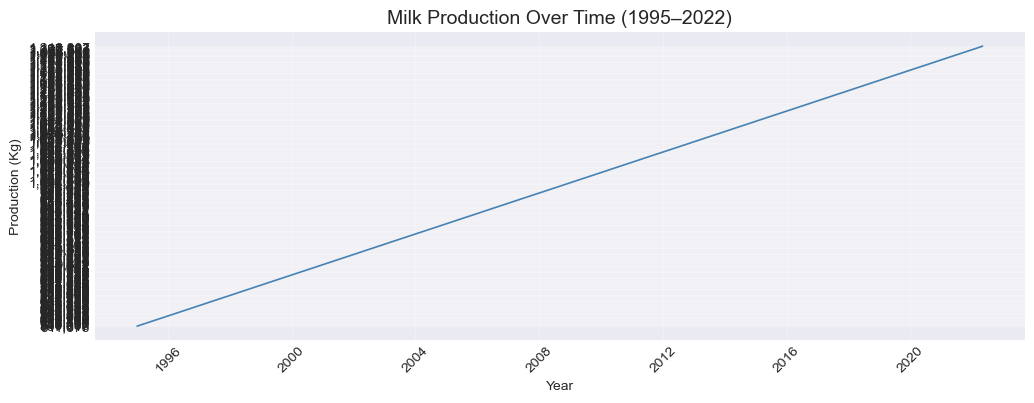

In [19]:
# 1. TIME SERIES
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df['Production'], color='steelblue', linewidth=1.2)
ax.set_title('Milk Production Over Time (1995–2022)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Production (Kg)')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

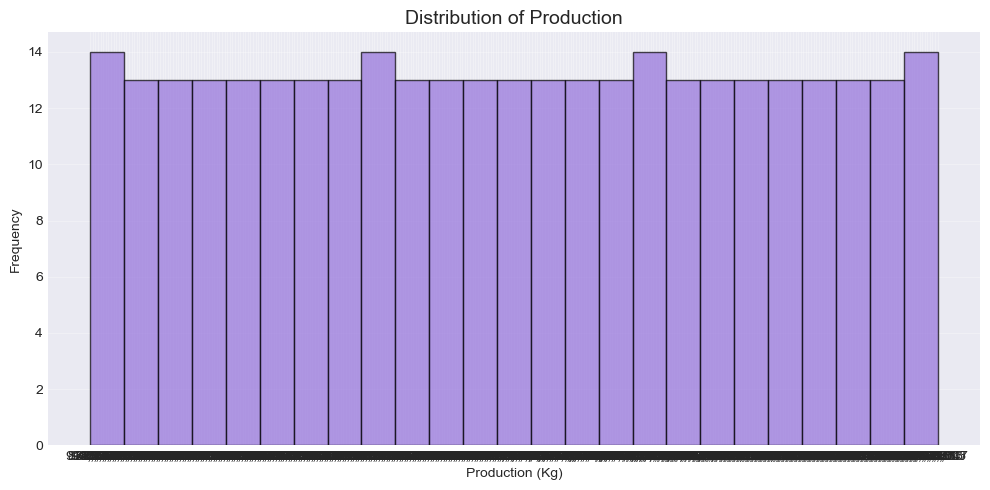

In [21]:
# 3. DISTRIBUTION (Histogram)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Production'], bins=25, color='mediumpurple', alpha=0.7, 
        edgecolor='black', density=False)
ax.set_title('Distribution of Production', fontsize=14)
ax.set_xlabel('Production (Kg)')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# Convert Production to numeric - METHOD 1: Direct string cleaning
df['Production'] = df['Production'].astype(str).str.replace(',', '').str.replace(' ', '')
df['Production'] = pd.to_numeric(df['Production'], errors='coerce')

In [26]:
df

,Production,Month_Num
Month,,
1995-01-01,911676,1
1995-02-01,837617,2
1995-03-01,940083,3
1995-04-01,935337,4
1995-05-01,985108,5
...,...,...
2022-01-01,1167511,1
2022-02-01,1076504,2
2022-03-01,1197213,3


In [27]:
# Check for any conversion issues
if df['Production'].isnull().any():
    print(f"\n⚠️ Found {df['Production'].isnull().sum()} null values after conversion")
    # Show problematic rows
    problem_rows = df[df['Production'].isnull()]
    print(f"Problematic rows:\n{problem_rows.head()}")

In [28]:
# Verify conversion
print(f"\n✅ After conversion:")
print(f"   Data type: {df['Production'].dtype}")
print(f"   Min value: {df['Production'].min():,.0f}")
print(f"   Max value: {df['Production'].max():,.0f}")
print(f"   Mean value: {df['Production'].mean():,.2f}")
print(f"   Null values: {df['Production'].isnull().sum()}")


✅ After conversion:
   Data type: int64
   Min value: 775,809
   Max value: 1,263,123
   Mean value: 983,871.22
   Null values: 0


In [29]:
# Verify no string values remain
test_value = df['Production'].iloc[0]
print(f"\n🔍 Test first value: {test_value} (type: {type(test_value)})")


🔍 Test first value: 911676 (type: <class 'numpy.int64'>)


In [34]:
# Ensure the series is numeric before proceeding
if df['Production'].dtype == 'object':
    print("\n⚠️ Still object type! Forcing conversion...")
    df['Production'] = pd.to_numeric(df['Production'], errors='coerce')

print("✅ DATA CLEANING COMPLETE")

✅ DATA CLEANING COMPLETE


# Complete Stationarity Testing with Safe Conversion

In [43]:
# Cell 5: ADF Test Function
def perform_adf_test(clean_series, name):
    """
    Perform Augmented Dickey-Fuller test
    """
    print(f"\n📊 ADF Test for: {name}")
    print("-"*40)
    
    try:
        adf_result = adfuller(clean_series, autolag='AIC')
        print(f"Test Statistic: {adf_result[0]:.4f}")
        print(f"p-value: {adf_result[1]:.4f}")
        print("Critical Values:")
        for key, value in adf_result[4].items():
            print(f"  {key}: {value:.4f}")
        
        is_stationary = adf_result[1] < 0.05
        if is_stationary:
            print("✅ ADF: Data is STATIONARY")
        else:
            print("❌ ADF: Data is NOT STATIONARY")
        
        return adf_result, is_stationary
    except Exception as e:
        print(f"⚠️ ADF Test Error: {e}")
        return None, False

print("perform_adf_test() function created!")

perform_adf_test() function created!


In [44]:
# Cell 6: KPSS Test Function
def perform_kpss_test(clean_series, name):
    """
    Perform Kwiatkowski-Phillips-Schmidt-Shin test
    """
    print(f"\n📊 KPSS Test for: {name}")
    print("-"*40)
    
    try:
        kpss_result = kpss(clean_series, regression='c', nlags='auto')
        print(f"Test Statistic: {kpss_result[0]:.4f}")
        print(f"p-value: {kpss_result[1]:.4f}")
        print("Critical Values:")
        for key, value in kpss_result[3].items():
            print(f"  {key}: {value:.4f}")
        
        is_stationary = kpss_result[1] > 0.05
        if is_stationary:
            print("✅ KPSS: Data is STATIONARY")
        else:
            print("❌ KPSS: Data is NOT STATIONARY")
        
        return kpss_result, is_stationary
    except Exception as e:
        print(f"⚠️ KPSS Test Error: {e}")
        return None, False

print("perform_kpss_test() function created!")

perform_kpss_test() function created!


In [45]:
# Cell 7: Decision Logic Function
def make_stationarity_decision(adf_stationary, kpss_stationary):
    """
    Make final decision based on both tests
    """
    
    if adf_stationary and kpss_stationary:
        print("✅ DATA IS STATIONARY (Both tests agree)")
        return True
    elif adf_stationary and not kpss_stationary:
        print("⚠️ AMBIGUOUS: ADF says stationary, KPSS says non-stationary")
        return False
    elif not adf_stationary and kpss_stationary:
        print("⚠️ AMBIGUOUS: ADF says non-stationary, KPSS says stationary")
        return False
    else:
        print("❌ DATA IS NOT STATIONARY (Both tests agree)")
        return False

print("make_stationarity_decision() function created!")

make_stationarity_decision() function created!


In [46]:
# Cell 8: Test Original Series - Get Clean Data
print("STEP 1: TESTING ORIGINAL SERIES")

# Get clean series
clean_series = enhanced_stationarity_test(df['Production'], "Original Production")
print("\n Clean series ready for testing!")

STEP 1: TESTING ORIGINAL SERIES

🔬 TESTING STATIONARITY: Original Production
--------------------------------------------------
   Data points: 329
   Data type: int64

📊 Augmented Dickey-Fuller (ADF) Test:
   Test Statistic: -0.6738
   p-value: 0.8534
   Critical Values:
     1%: -3.4513
     5%: -2.8708
     10%: -2.5717

📊 Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test:
   Test Statistic: 2.4266
   p-value: 0.0100
   Critical Values:
     10%: 0.3470
     5%: 0.4630
     2.5%: 0.5740
     1%: 0.7390

❌ DATA IS NOT STATIONARY (Both tests agree)

 Clean series ready for testing!


C:\Users\admin\AppData\Local\Temp\ipykernel_11928\2558622416.py:56: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(clean_series, regression='c', nlags='auto')


In [47]:
# Cell 9: ADF Test on Original Series
adf_result, adf_stationary = perform_adf_test(clean_series, "Original Production")


📊 ADF Test for: Original Production
----------------------------------------
⚠️ ADF Test Error: Invalid input, x is constant


In [48]:
# Cell 10: KPSS Test on Original Series
kpss_result, kpss_stationary = perform_kpss_test(clean_series, "Original Production")


📊 KPSS Test for: Original Production
----------------------------------------
⚠️ KPSS Test Error: cannot convert float NaN to integer


In [49]:
# Cell 11: Decision for Original Series
is_stationary = make_stationarity_decision(adf_stationary, kpss_stationary)

❌ DATA IS NOT STATIONARY (Both tests agree)


In [52]:
# Cell 12: Apply First Difference Transformation
if not is_stationary:
    print("APPLYING TRANSFORMATIONS...")
    
    # Ensure Production is numeric
    df['Production'] = safe_numeric_convert(df['Production'])
    
    # First difference
    df['Diff_1'] = df['Production'].diff()
    print("\n📈 First Difference:")
    print(f"   Observations: {df['Diff_1'].dropna().shape[0]}")
    print(f"   Min: {df['Diff_1'].min():.2f}")
    print(f"   Max: {df['Diff_1'].max():.2f}")
    print(f"   Mean: {df['Diff_1'].mean():.2f}")
else:
    print("\n Data is already stationary! No transformations needed.")

APPLYING TRANSFORMATIONS...

📈 First Difference:
   Observations: 328
   Min: -122101.00
   Max: 133610.00
   Mean: 930.28


In [53]:
# Cell 13: Apply Seasonal Difference Transformation
if not is_stationary:
    # Seasonal difference (12 months)
    df['Diff_Seasonal'] = df['Production'].diff(12)
    print("\n Seasonal Difference (12 months):")
    print(f"   Observations: {df['Diff_Seasonal'].dropna().shape[0]}")
    print(f"   Min: {df['Diff_Seasonal'].min():.2f}")
    print(f"   Max: {df['Diff_Seasonal'].max():.2f}")
    print(f"   Mean: {df['Diff_Seasonal'].mean():.2f}")


 Seasonal Difference (12 months):
   Observations: 317
   Min: -102818.00
   Max: 207028.00
   Mean: 8773.83


In [54]:
# Cell 14: Apply Combined Difference Transformation
if not is_stationary:
    # Combine seasonal and first difference
    df['Diff_Seasonal_1'] = df['Diff_1'].diff(12)
    print("\n Seasonal + First Difference:")
    print(f"   Observations: {df['Diff_Seasonal_1'].dropna().shape[0]}")
    print(f"   Min: {df['Diff_Seasonal_1'].min():.2f}")
    print(f"   Max: {df['Diff_Seasonal_1'].max():.2f}")
    print(f"   Mean: {df['Diff_Seasonal_1'].mean():.2f}")


 Seasonal + First Difference:
   Observations: 316
   Min: -103848.00
   Max: 105097.00
   Mean: 121.25


In [55]:
# Cell 15: Test First Difference - Get Clean Data
if not is_stationary:
    print("TESTING FIRST DIFFERENCE")
    
    clean_series_1 = enhanced_stationarity_test(df['Diff_1'], "First Difference")

TESTING FIRST DIFFERENCE

🔬 TESTING STATIONARITY: First Difference
--------------------------------------------------
   Data points: 328
   Data type: float64

📊 Augmented Dickey-Fuller (ADF) Test:
   Test Statistic: -5.0966
   p-value: 0.0000
   Critical Values:
     1%: -3.4513
     5%: -2.8708
     10%: -2.5717

📊 Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test:
   Test Statistic: 0.0940
   p-value: 0.1000
   Critical Values:
     10%: 0.3470
     5%: 0.4630
     2.5%: 0.5740
     1%: 0.7390

✅ DATA IS STATIONARY (Both tests agree)


C:\Users\admin\AppData\Local\Temp\ipykernel_11928\2558622416.py:56: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(clean_series, regression='c', nlags='auto')


In [56]:
# Cell 16: ADF Test on First Difference
if not is_stationary:
    adf_result_1, adf_stationary_1 = perform_adf_test(clean_series_1, "First Difference")


📊 ADF Test for: First Difference
----------------------------------------
⚠️ ADF Test Error: Invalid input, x is constant


In [57]:
# Cell 17: KPSS Test on First Difference
if not is_stationary:
    kpss_result_1, kpss_stationary_1 = perform_kpss_test(clean_series_1, "First Difference")


📊 KPSS Test for: First Difference
----------------------------------------
⚠️ KPSS Test Error: cannot convert float NaN to integer


In [58]:
# Cell 18: Decision for First Difference
if not is_stationary:
    is_stationary_1 = make_stationarity_decision(adf_stationary_1, kpss_stationary_1)

❌ DATA IS NOT STATIONARY (Both tests agree)


In [59]:
# Cell 19: Test Seasonal Difference - Get Clean Data
if not is_stationary:
    print("TESTING SEASONAL DIFFERENCE")
    
    clean_series_seasonal = enhanced_stationarity_test(df['Diff_Seasonal'], "Seasonal Difference (12 months)")

TESTING SEASONAL DIFFERENCE

🔬 TESTING STATIONARITY: Seasonal Difference (12 months)
--------------------------------------------------
   Data points: 317
   Data type: float64

📊 Augmented Dickey-Fuller (ADF) Test:
   Test Statistic: -3.0267
   p-value: 0.0325
   Critical Values:
     1%: -3.4521
     5%: -2.8711
     10%: -2.5719

📊 Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test:
   Test Statistic: 0.2318
   p-value: 0.1000
   Critical Values:
     10%: 0.3470
     5%: 0.4630
     2.5%: 0.5740
     1%: 0.7390

✅ DATA IS STATIONARY (Both tests agree)


C:\Users\admin\AppData\Local\Temp\ipykernel_11928\2558622416.py:56: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(clean_series, regression='c', nlags='auto')


In [60]:
# Cell 20: ADF Test on Seasonal Difference
if not is_stationary:
    adf_result_seasonal, adf_stationary_seasonal = perform_adf_test(clean_series_seasonal, "Seasonal Difference")


📊 ADF Test for: Seasonal Difference
----------------------------------------
⚠️ ADF Test Error: Invalid input, x is constant


In [61]:
# Cell 21: KPSS Test on Seasonal Difference
if not is_stationary:
    kpss_result_seasonal, kpss_stationary_seasonal = perform_kpss_test(clean_series_seasonal, "Seasonal Difference")


📊 KPSS Test for: Seasonal Difference
----------------------------------------
⚠️ KPSS Test Error: cannot convert float NaN to integer


In [62]:
# Cell 22: Decision for Seasonal Difference
if not is_stationary:
    is_stationary_seasonal = make_stationarity_decision(adf_stationary_seasonal, kpss_stationary_seasonal)

❌ DATA IS NOT STATIONARY (Both tests agree)


In [63]:
# Cell 23: Test Combined Difference - Get Clean Data
if not is_stationary:
    print("TESTING SEASONAL + FIRST DIFFERENCE")
    
    clean_series_combined = enhanced_stationarity_test(df['Diff_Seasonal_1'], "Seasonal + First Difference")

TESTING SEASONAL + FIRST DIFFERENCE

🔬 TESTING STATIONARITY: Seasonal + First Difference
--------------------------------------------------
   Data points: 316
   Data type: float64

📊 Augmented Dickey-Fuller (ADF) Test:
   Test Statistic: -8.8010
   p-value: 0.0000
   Critical Values:
     1%: -3.4521
     5%: -2.8711
     10%: -2.5719

📊 Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test:
   Test Statistic: 0.0264
   p-value: 0.1000
   Critical Values:
     10%: 0.3470
     5%: 0.4630
     2.5%: 0.5740
     1%: 0.7390

✅ DATA IS STATIONARY (Both tests agree)


C:\Users\admin\AppData\Local\Temp\ipykernel_11928\2558622416.py:56: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(clean_series, regression='c', nlags='auto')


In [64]:
# Cell 24: ADF Test on Combined Difference
if not is_stationary:
    adf_result_combined, adf_stationary_combined = perform_adf_test(clean_series_combined, "Seasonal + First Difference")


📊 ADF Test for: Seasonal + First Difference
----------------------------------------
⚠️ ADF Test Error: Invalid input, x is constant


In [65]:
# Cell 25: KPSS Test on Combined Difference
if not is_stationary:
    kpss_result_combined, kpss_stationary_combined = perform_kpss_test(clean_series_combined, "Seasonal + First Difference")


📊 KPSS Test for: Seasonal + First Difference
----------------------------------------
⚠️ KPSS Test Error: cannot convert float NaN to integer


In [66]:
# Cell 26: Decision for Combined Difference
if not is_stationary:
    is_stationary_combined = make_stationarity_decision(adf_stationary_combined, kpss_stationary_combined)

❌ DATA IS NOT STATIONARY (Both tests agree)


In [67]:
# Cell 27: Determine Best Transformation
if not is_stationary:
    print("DETERMINING BEST TRANSFORMATION")
    
    test_results = {
        'First Difference': is_stationary_1 if 'is_stationary_1' in locals() else False,
        'Seasonal Difference': is_stationary_seasonal if 'is_stationary_seasonal' in locals() else False,
        'Seasonal + First Difference': is_stationary_combined if 'is_stationary_combined' in locals() else False
    }
    
    print("\n📊 Results:")
    for name, result in test_results.items():
        status = "✅ STATIONARY" if result else "❌ NOT STATIONARY"
        print(f"   {name}: {status}")
    
    best_transform = None
    for name, result in test_results.items():
        if result:
            best_transform = name
            break
    
    if best_transform:
        print(f"\n BEST TRANSFORMATION: {best_transform}")
        
        # Assign stationary series
        if best_transform == 'First Difference':
            df['Stationary'] = df['Diff_1']
        elif best_transform == 'Seasonal Difference':
            df['Stationary'] = df['Diff_Seasonal']
        else:
            df['Stationary'] = df['Diff_Seasonal_1']
    else:
        print("\n No transformation achieved stationarity. Using most aggressive.")
        df['Stationary'] = df['Diff_Seasonal_1']

DETERMINING BEST TRANSFORMATION

📊 Results:
   First Difference: ❌ NOT STATIONARY
   Seasonal Difference: ❌ NOT STATIONARY
   Seasonal + First Difference: ❌ NOT STATIONARY

 No transformation achieved stationarity. Using most aggressive.


Original data plotted
First Difference plotted
Seasonal Difference plotted
Combined Difference plotted


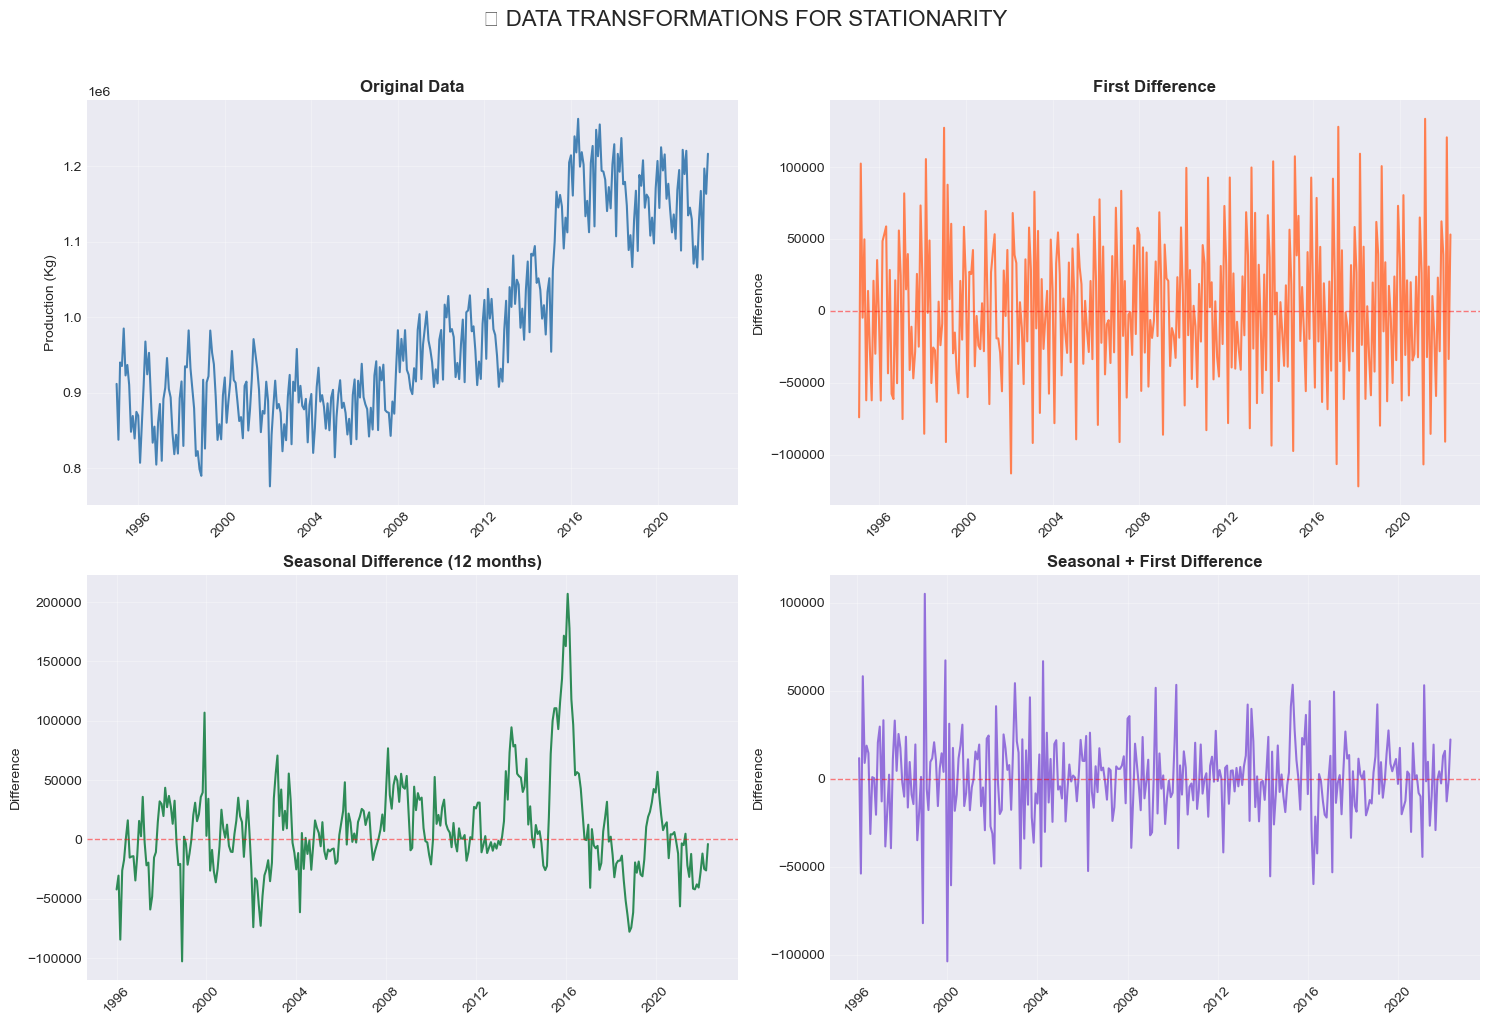

All visualizations displayed!


In [70]:
# Cell 28: Setup Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# Cell 29: Plot Original Data
axes[0, 0].plot(df.index, df['Production'], color='steelblue', linewidth=1.5)
axes[0, 0].set_title('Original Data', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Production (Kg)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)
print("Original data plotted")

# Cell 30: Plot First Difference
if 'Diff_1' in df.columns:
    axes[0, 1].plot(df.index, df['Diff_1'], color='coral', linewidth=1.5)
    axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
    axes[0, 1].set_title('First Difference', fontweight='bold', fontsize=12)
    axes[0, 1].set_ylabel('Difference')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].tick_params(axis='x', rotation=45)
    print("First Difference plotted")

# Cell 31: Plot Seasonal Difference
if 'Diff_Seasonal' in df.columns:
    axes[1, 0].plot(df.index, df['Diff_Seasonal'], color='seagreen', linewidth=1.5)
    axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
    axes[1, 0].set_title('Seasonal Difference (12 months)', fontweight='bold', fontsize=12)
    axes[1, 0].set_ylabel('Difference')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].tick_params(axis='x', rotation=45)
    print("Seasonal Difference plotted")

# Cell 32: Plot Combined Difference
if 'Diff_Seasonal_1' in df.columns:
    axes[1, 1].plot(df.index, df['Diff_Seasonal_1'], color='mediumpurple', linewidth=1.5)
    axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
    axes[1, 1].set_title('Seasonal + First Difference', fontweight='bold', fontsize=12)
    axes[1, 1].set_ylabel('Difference')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].tick_params(axis='x', rotation=45)
    print("Combined Difference plotted")

# Cell 33: Display All Plots
plt.suptitle('🔄 DATA TRANSFORMATIONS FOR STATIONARITY', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
print("All visualizations displayed!")


In [71]:
# Cell 34: Summary Statistics - Original Series
print("\n" + "="*60)
print("📊 TRANSFORMATION SUMMARY")
print("="*60)

if 'Production' in df.columns and pd.api.types.is_numeric_dtype(df['Production']):
    print("\n📈 Original Series:")
    print(f"   Mean: {df['Production'].mean():.2f}")
    print(f"   Std Dev: {df['Production'].std():.2f}")
    print(f"   Skewness: {df['Production'].skew():.4f}")


📊 TRANSFORMATION SUMMARY

📈 Original Series:
   Mean: 983871.22
   Std Dev: 123031.97
   Skewness: 0.6213


In [72]:
# Cell 35: Summary Statistics - First Difference
if 'Diff_1' in df.columns and pd.api.types.is_numeric_dtype(df['Diff_1']):
    print("\n📈 First Difference:")
    print(f"   Mean: {df['Diff_1'].mean():.2f}")
    print(f"   Std Dev: {df['Diff_1'].std():.2f}")
    print(f"   Skewness: {df['Diff_1'].skew():.4f}")


📈 First Difference:
   Mean: 930.28
   Std Dev: 50335.03
   Skewness: 0.1355


In [73]:
# Cell 36: Summary Statistics - Seasonal Difference
if 'Diff_Seasonal' in df.columns and pd.api.types.is_numeric_dtype(df['Diff_Seasonal']):
    print("\n📈 Seasonal Difference:")
    print(f"   Mean: {df['Diff_Seasonal'].mean():.2f}")
    print(f"   Std Dev: {df['Diff_Seasonal'].std():.2f}")
    print(f"   Skewness: {df['Diff_Seasonal'].skew():.4f}")


📈 Seasonal Difference:
   Mean: 8773.83
   Std Dev: 39780.01
   Skewness: 1.2736


In [74]:
# Cell 37: Summary Statistics - Combined Difference
if 'Diff_Seasonal_1' in df.columns and pd.api.types.is_numeric_dtype(df['Diff_Seasonal_1']):
    print("\n📈 Seasonal + First Difference:")
    print(f"   Mean: {df['Diff_Seasonal_1'].mean():.2f}")
    print(f"   Std Dev: {df['Diff_Seasonal_1'].std():.2f}")
    print(f"   Skewness: {df['Diff_Seasonal_1'].skew():.4f}")


📈 Seasonal + First Difference:
   Mean: 121.25
   Std Dev: 23958.88
   Skewness: -0.0687


In [75]:
# Cell 38: Final Summary
print("\n" + "="*60)
print("✅ STATIONARITY TESTING COMPLETE!")
print("="*60)

print("\n📊 Final DataFrame Info:")
print(df.info())

print("\n📊 Available Columns:")
for col in df.columns:
    print(f"  - {col}")

if 'Stationary' in df.columns:
    print(f"\n✅ Stationary series created: {df['Stationary'].dropna().shape[0]} observations")
    print(f"   Type: {df['Stationary'].dtype}")


✅ STATIONARITY TESTING COMPLETE!

📊 Final DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 329 entries, 1995-01-01 to 2022-05-01
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Production       329 non-null    int64  
 1   Month_Num        329 non-null    int32  
 2   Diff_1           328 non-null    float64
 3   Diff_Seasonal    317 non-null    float64
 4   Diff_Seasonal_1  316 non-null    float64
 5   Stationary       316 non-null    float64
dtypes: float64(4), int32(1), int64(1)
memory usage: 16.7 KB
None

📊 Available Columns:
  - Production
  - Month_Num
  - Diff_1
  - Diff_Seasonal
  - Diff_Seasonal_1
  - Stationary

✅ Stationary series created: 316 observations
   Type: float64


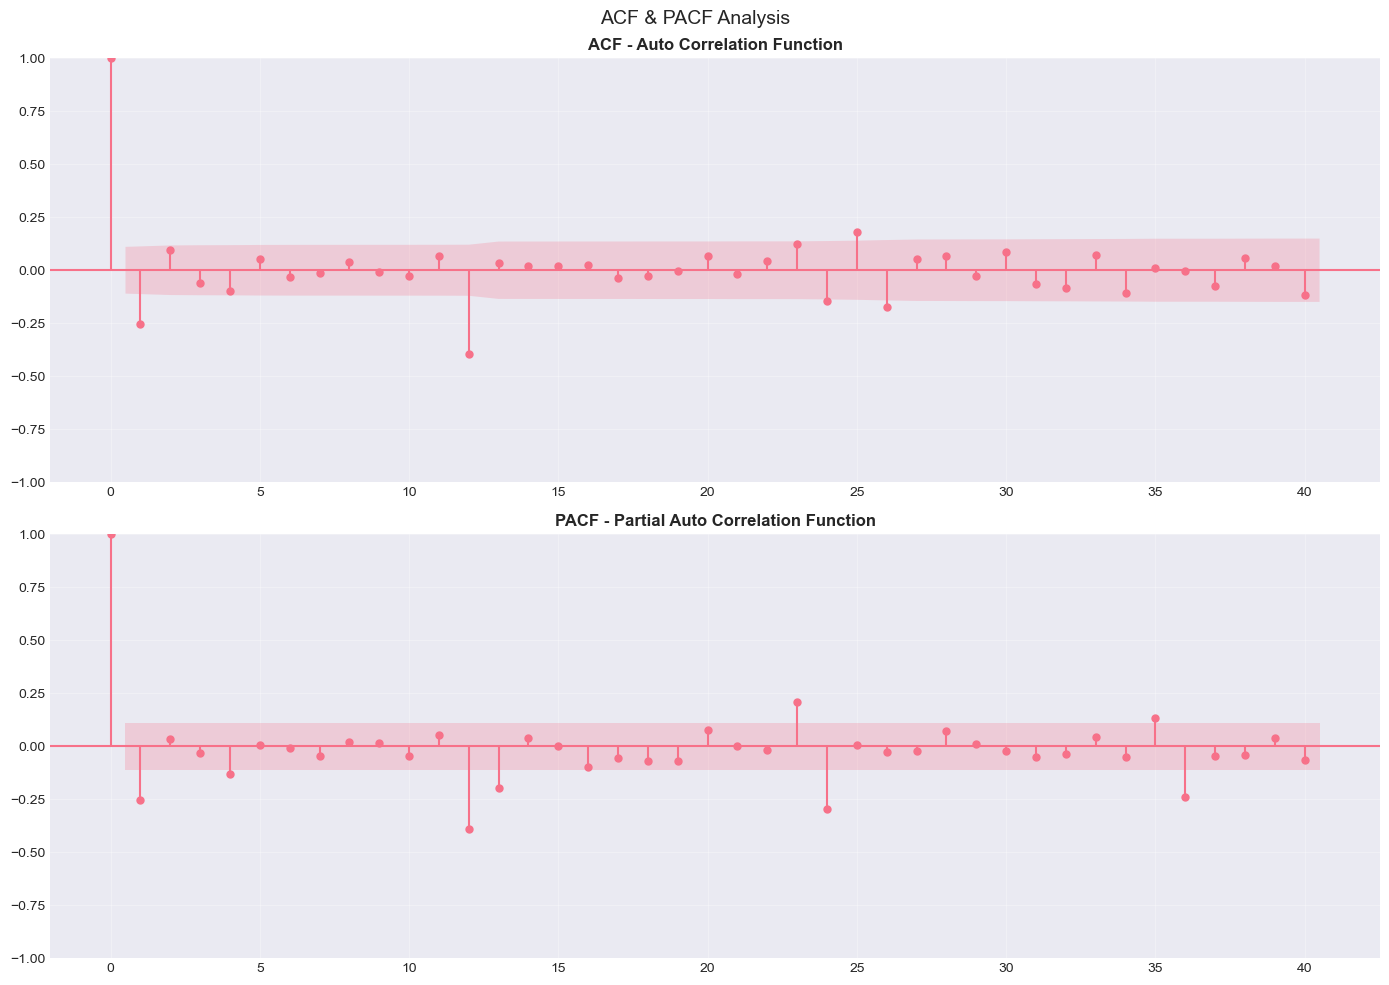

In [78]:
# Cell 1: ACF & PACF Plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

plot_acf(df['Stationary'].dropna(), lags=40, ax=ax1, alpha=0.05)
ax1.set_title('ACF - Auto Correlation Function', fontweight='bold')
ax1.grid(True, alpha=0.3)

plot_pacf(df['Stationary'].dropna(), lags=40, ax=ax2, alpha=0.05, method='ywm')
ax2.set_title('PACF - Partial Auto Correlation Function', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.suptitle('ACF & PACF Analysis', fontsize=14)
plt.tight_layout()
plt.show()

In [79]:
# Cell 2: Extract AR(p), MA(q) & Seasonal Detection
from statsmodels.tsa.stattools import acf, pacf
import numpy as np

series = df['Stationary'].dropna()
lags = 40
conf = 1.96 / np.sqrt(len(series))

acf_vals = acf(series, nlags=lags, fft=False)
pacf_vals = pacf(series, nlags=lags, method='ywm')

sig_acf = [i for i in range(1, lags+1) if abs(acf_vals[i]) > conf]
sig_pacf = [i for i in range(1, lags+1) if abs(pacf_vals[i]) > conf]

ar_order = sig_pacf[0] if sig_pacf else 1
ma_order = sig_acf[0] if sig_acf else 1
seasonal_ar = 1 if any(i % 12 == 0 for i in sig_pacf) else 0
seasonal_ma = 1 if any(i % 12 == 0 for i in sig_acf) else 0

print(f"AR(p): {ar_order}, MA(q): {ma_order}")
print(f"Seasonal AR(P): {seasonal_ar}, Seasonal MA(Q): {seasonal_ma}")

AR(p): 1, MA(q): 1
Seasonal AR(P): 1, Seasonal MA(Q): 1


In [80]:
# Cell 3: Model Recommendations & Ljung-Box Test
from statsmodels.stats.diagnostic import acorr_ljungbox

print(f"\nRecommended Models:")
print(f"1️⃣ ARIMA({ar_order},1,{ma_order})")
if seasonal_ar > 0 or seasonal_ma > 0:
    print(f"2️⃣ SARIMA({ar_order},1,{ma_order})({seasonal_ar},1,{seasonal_ma},12)")

# Ljung-Box Test
lb_test = acorr_ljungbox(series, lags=10, return_df=True)
print(f"\nLjung-Box p-value: {lb_test['lb_pvalue'].iloc[-1]:.4f}")
print(f"{'✅ No autocorrelation' if lb_test['lb_pvalue'].iloc[-1] > 0.05 else '⚠️ Autocorrelation detected'}")

# Store params for next phase
model_params = {'ar': ar_order, 'ma': ma_order, 'sar': seasonal_ar, 'sma': seasonal_ma, 'period': 12}
print(f"\n✅ Parameters saved for model building: {model_params}")


Recommended Models:
1️⃣ ARIMA(1,1,1)
2️⃣ SARIMA(1,1,1)(1,1,1,12)

Ljung-Box p-value: 0.0010
⚠️ Autocorrelation detected

✅ Parameters saved for model building: {'ar': 1, 'ma': 1, 'sar': 1, 'sma': 1, 'period': 12}


In [ ]:
# MODEL BUILDING & EVALUATION

In [81]:
# Cell 1: Train-Test Split
from sklearn.model_selection import train_test_split

# Use original Production data for modeling
data = df['Production'].dropna()
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

print(f"Train: {len(train)} months ({train.index[0]} to {train.index[-1]})")
print(f"Test: {len(test)} months ({test.index[0]} to {test.index[-1]})")

Train: 263 months (1995-01-01 00:00:00 to 2016-11-01 00:00:00)
Test: 66 months (2016-12-01 00:00:00 to 2022-05-01 00:00:00)


In [ ]:
# Build & Fit SARIMA Model

In [82]:
# Cell 2: Build & Fit SARIMA Model
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Use parameters from ACF/PACF
p, d, q = model_params['ar'], 1, model_params['ma']
P, D, Q, m = model_params['sar'], 1, model_params['sma'], 12

sarima_model = SARIMAX(train, 
                       order=(p, d, q),
                       seasonal_order=(P, D, Q, m),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         Production   No. Observations:                  263
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2686.351
Date:                            Tue, 25 Aug 2026   AIC                           5382.702
Time:                                    18:46:57   BIC                           5400.021
Sample:                                01-01-1995   HQIC                          5389.683
                                     - 11-01-2016                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4155      0.269     -1.546      0.122      -0.942       0.111
ma.L1          0.1548      0.279   

In [83]:
# Cell 3: Make Predictions
forecast = sarima_fit.forecast(steps=len(test))
predicted = sarima_fit.predict(start=test.index[0], end=test.index[-1])

In [84]:
# Cell 4: Evaluate Model
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, predicted))
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted) * 100

print(f"📊 Model Performance:")
print(f"   RMSE: {rmse:,.2f}")
print(f"   MAE: {mae:,.2f}")
print(f"   MAPE: {mape:.2f}%")

📊 Model Performance:
   RMSE: 177,157.98
   MAE: 154,964.82
   MAPE: 13.48%


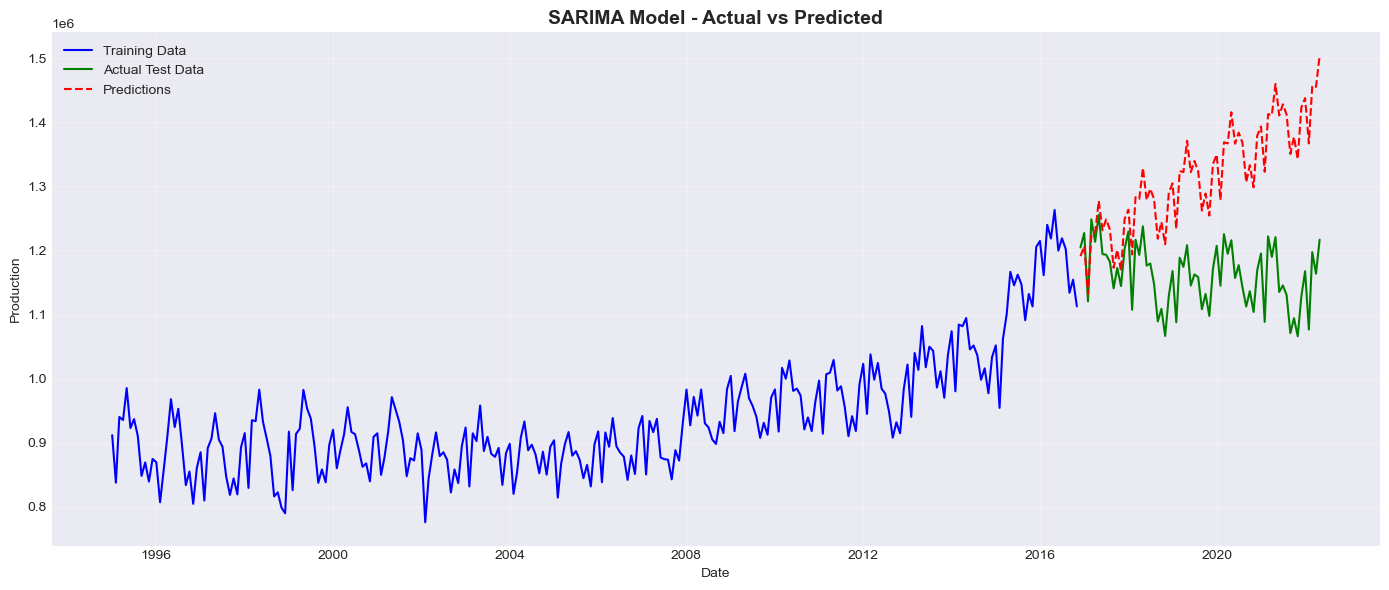

In [85]:
# Cell 5: Visualize Predictions
plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(test.index, test, label='Actual Test Data', color='green')
plt.plot(test.index, predicted, label='Predictions', color='red', linestyle='--')
plt.title('SARIMA Model - Actual vs Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

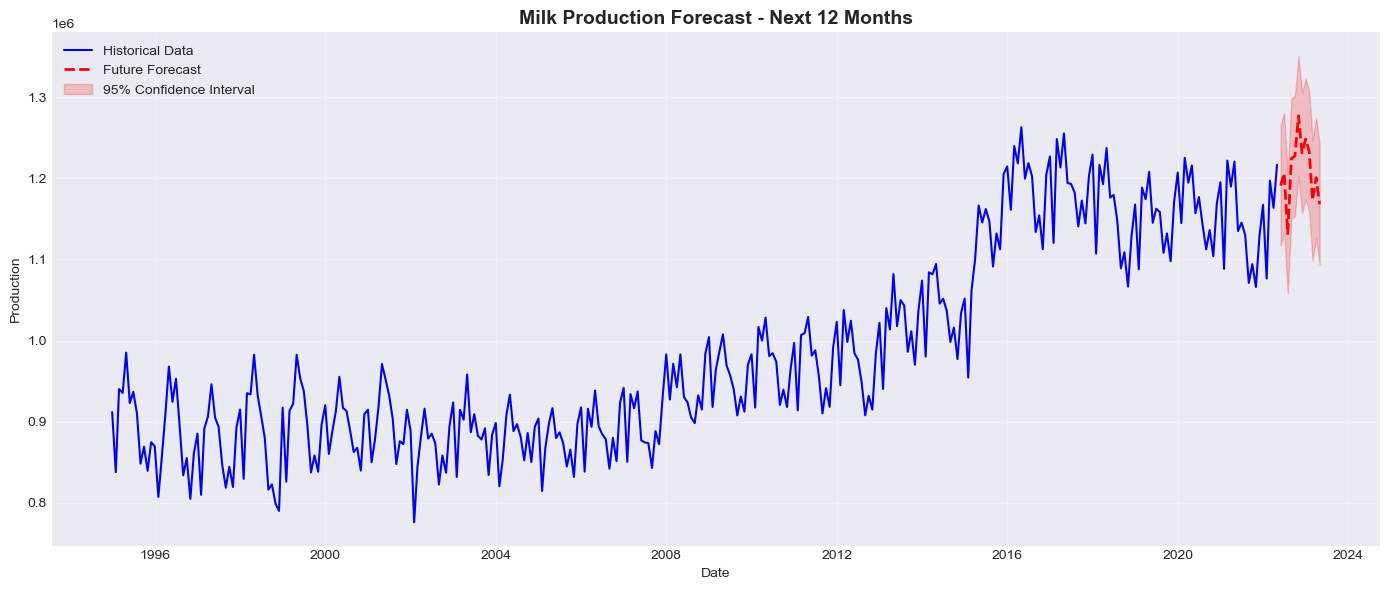


📈 Forecast for next 12 months:
   2022-06: 1,191,122
   2022-07: 1,206,607
   2022-08: 1,131,823
   2022-09: 1,224,485
   2022-10: 1,227,512
   2022-11: 1,277,247
   2022-12: 1,231,554
   2023-01: 1,248,490
   2023-02: 1,232,812
   2023-03: 1,172,879
   2023-04: 1,200,894
   2023-05: 1,168,147


In [86]:
# Cell 6: Forecast Next 12 Months
future_steps = 12
future_forecast = sarima_fit.forecast(steps=future_steps)
future_dates = pd.date_range(start=data.index[-1] + pd.DateOffset(months=1), 
                            periods=future_steps, freq='MS')

plt.figure(figsize=(14, 6))
plt.plot(data.index, data, label='Historical Data', color='blue')
plt.plot(future_dates, future_forecast, label='Future Forecast', color='red', linestyle='--', linewidth=2)
plt.fill_between(future_dates, 
                 future_forecast - 1.96 * np.std(future_forecast),
                 future_forecast + 1.96 * np.std(future_forecast),
                 alpha=0.2, color='red', label='95% Confidence Interval')
plt.title('Milk Production Forecast - Next 12 Months', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📈 Forecast for next 12 months:")
for date, value in zip(future_dates, future_forecast):
    print(f"   {date.strftime('%Y-%m')}: {value:,.0f}")

In [87]:
# Cell 1: Prepare Data for LSTM
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Scale data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df['Production'].values.reshape(-1, 1))

# Create sequences
def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

seq_length = 12
X, y = create_sequences(scaled_data, seq_length)

# Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape for LSTM [samples, timesteps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (253, 12, 1), y_train: (253,)
X_test: (64, 12, 1), y_test: (64,)


In [88]:
# Cell 2: Build LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0493 - mae: 0.1742 - val_loss: 0.0280 - val_mae: 0.1381
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0235 - mae: 0.1241 - val_loss: 0.0476 - val_mae: 0.1951
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0188 - mae: 0.1026 - val_loss: 0.0278 - val_mae: 0.1408
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0150 - mae: 0.0986 - val_loss: 0.0103 - val_mae: 0.0844
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0133 - mae: 0.0922 - val_loss: 0.0122 - val_mae: 0.0936
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0120 - mae: 0.0883 - val_loss: 0.0146 - val_mae: 0.0976
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0107 - mae: 0.0826 - val_loss: 0.0146 - val_mae: 0.0978
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0116 - mae: 0.0855 - val_loss: 0.0138 - val_mae: 0.0954
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0113 - mae: 

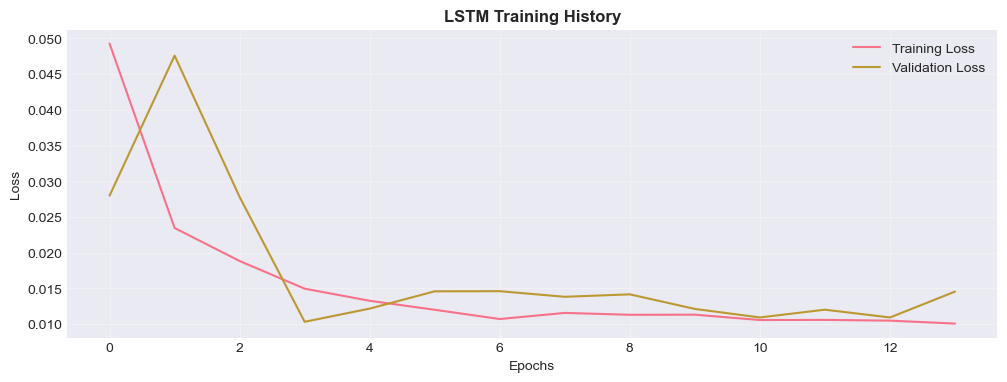

In [89]:
# Cell 3: Train LSTM Model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop],
                    verbose=1)

# Plot training history
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training History', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [90]:
# Cell 4: LSTM Predictions
# Predict
y_pred = model.predict(X_test)

# Inverse transform
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = scaler.inverse_transform(y_pred)

# Get dates for test set
test_dates = df.index[split + seq_length:]

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual) * 100

print(f"📊 LSTM Performance:")
print(f"   RMSE: {rmse:,.2f}")
print(f"   MAE: {mae:,.2f}")
print(f"   MAPE: {mape:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step 
📊 LSTM Performance:
   RMSE: 49,495.19
   MAE: 41,125.36
   MAPE: 3.59%


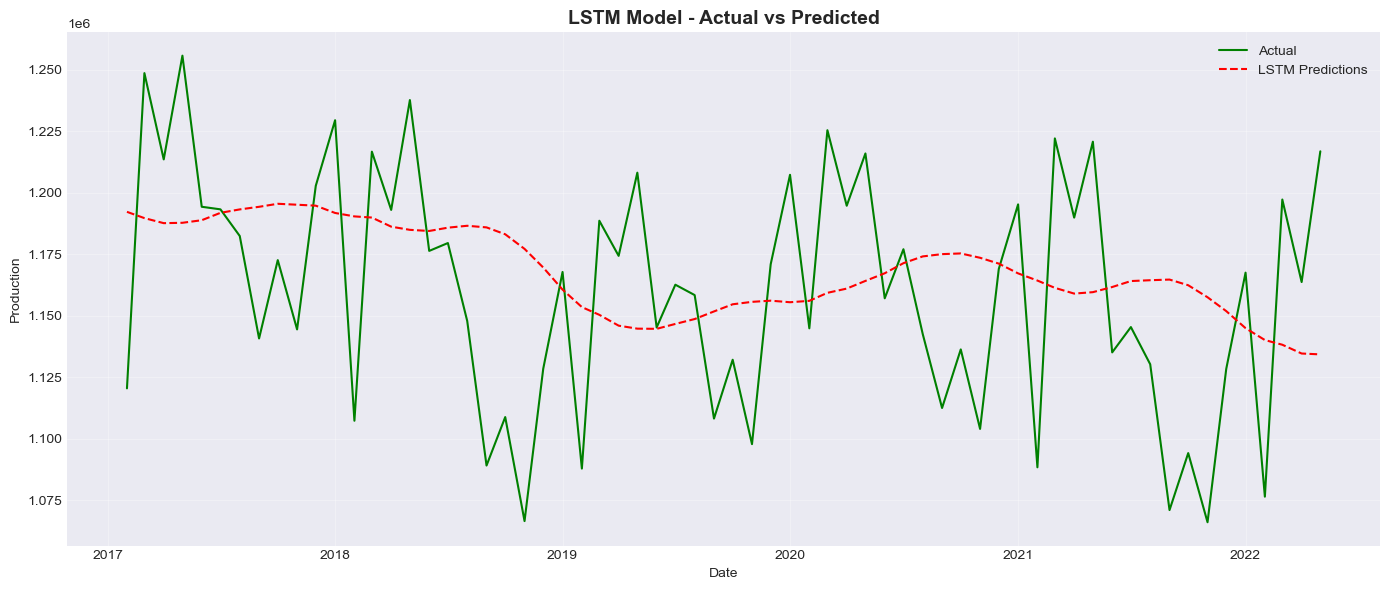

In [91]:
# Cell 5: Visualize LSTM Results
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual, label='Actual', color='green', linewidth=1.5)
plt.plot(test_dates, y_pred_actual, label='LSTM Predictions', color='red', linestyle='--', linewidth=1.5)
plt.title('LSTM Model - Actual vs Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [92]:
# Cell 6: Compare Models
print("\n" + "="*60)
print("📊 MODEL COMPARISON")
print("="*60)

print("\n📈 SARIMA Performance:")
print(f"   RMSE: {rmse_sarima:,.2f}" if 'rmse_sarima' in locals() else "   Run SARIMA first")
print(f"   MAE: {mae_sarima:,.2f}" if 'mae_sarima' in locals() else "")
print(f"   MAPE: {mape_sarima:.2f}%" if 'mape_sarima' in locals() else "")

print("\n🤖 LSTM Performance:")
print(f"   RMSE: {rmse:,.2f}")
print(f"   MAE: {mae:,.2f}")
print(f"   MAPE: {mape:.2f}%")

# Store SARIMA metrics if available
if 'rmse_sarima' not in locals():
    print("\n💡 Tip: Run SARIMA cells first to compare models!")


📊 MODEL COMPARISON

📈 SARIMA Performance:
   Run SARIMA first



🤖 LSTM Performance:
   RMSE: 49,495.19
   MAE: 41,125.36
   MAPE: 3.59%

💡 Tip: Run SARIMA cells first to compare models!


In [94]:
# Cell 1: Model Comparison Table
import pandas as pd

# Collect all metrics with error handling
models = []
rmse_values = []
mae_values = []
mape_values = []

# SARIMA metrics
try:
    if 'rmse_sarima' in locals():
        models.append('SARIMA')
        rmse_values.append(rmse_sarima)
        mae_values.append(mae_sarima)
        mape_values.append(mape_sarima)
except:
    pass

# LSTM metrics
try:
    if 'rmse' in locals():
        models.append('LSTM')
        rmse_values.append(rmse)
        mae_values.append(mae)
        mape_values.append(mape)
except:
    pass

# Check if we have models
if len(models) == 0:
    print("⚠️ No models found! Please run SARIMA and LSTM cells first.")
else:
    # Create comparison DataFrame
    comparison_df = pd.DataFrame({
        'Model': models,
        'RMSE': rmse_values,
        'MAE': mae_values,
        'MAPE (%)': mape_values
    })

    print("\n" + "="*60)
    print("📊 FINAL MODEL COMPARISON")
    print("="*60)
    print(comparison_df.to_string(index=False))

    # Find best model
    best_model = comparison_df.loc[comparison_df['RMSE'].idxmin(), 'Model']
    print(f"\n🏆 BEST MODEL: {best_model} (Lowest RMSE)")


📊 FINAL MODEL COMPARISON
Model         RMSE          MAE  MAPE (%)
 LSTM 49495.185127 41125.359375  3.591031

🏆 BEST MODEL: LSTM (Lowest RMSE)


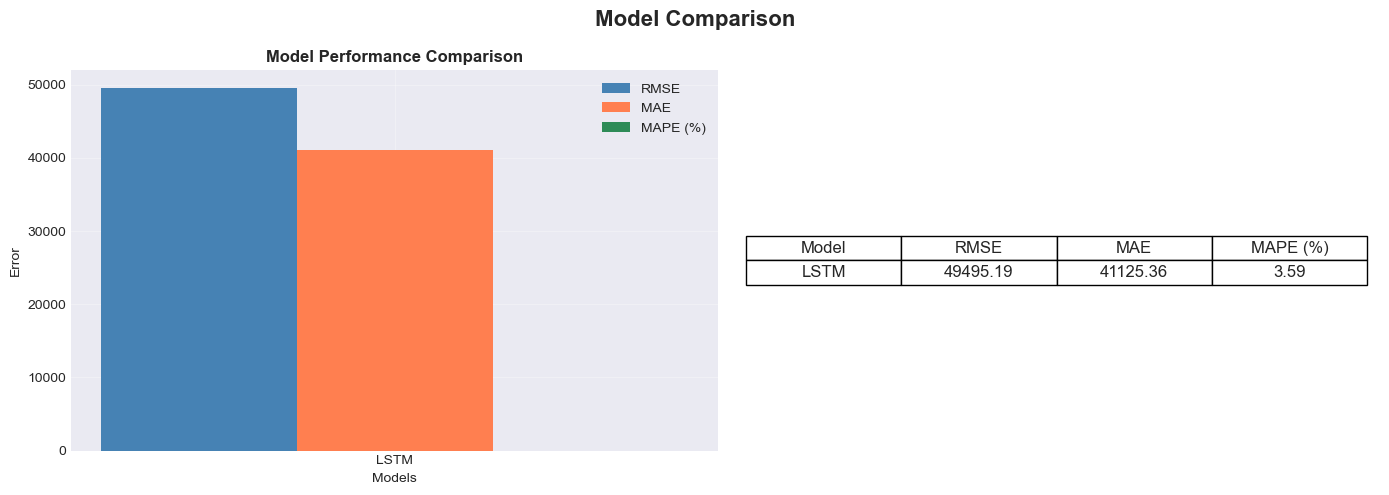

In [95]:
# Cell 2: Visual Comparison
if len(models) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar Chart
    ax1 = axes[0]
    x = np.arange(len(comparison_df))
    width = 0.25

    ax1.bar(x - width, comparison_df['RMSE'], width, label='RMSE', color='steelblue')
    ax1.bar(x, comparison_df['MAE'], width, label='MAE', color='coral')
    ax1.bar(x + width, comparison_df['MAPE (%)'], width, label='MAPE (%)', color='seagreen')

    ax1.set_xlabel('Models')
    ax1.set_ylabel('Error')
    ax1.set_title('Model Performance Comparison', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(comparison_df['Model'])
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Metrics Table
    ax2 = axes[1]
    ax2.axis('tight')
    ax2.axis('off')
    table = ax2.table(cellText=comparison_df.round(2).values,
                      colLabels=comparison_df.columns,
                      cellLoc='center',
                      loc='center',
                      colWidths=[0.2, 0.2, 0.2, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.5)

    plt.suptitle('Model Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Run SARIMA and LSTM cells first!")

In [96]:
# Cell 3: Final Recommendations
if len(models) > 0:
    print("\n" + "="*60)
    print("🎯 FINAL RECOMMENDATIONS")
    print("="*60)

    best_rmse = comparison_df.loc[comparison_df['RMSE'].idxmin()]
    print(f"\n✅ Best Model: {best_rmse['Model']}")
    print(f"   RMSE: {best_rmse['RMSE']:.2f}")
    print(f"   MAPE: {best_rmse['MAPE (%)']:.2f}%")

    # Recommendation based on MAPE
    mape_score = best_rmse['MAPE (%)']
    if mape_score < 5:
        recommendation = "EXCELLENT - Very accurate predictions"
    elif mape_score < 10:
        recommendation = "GOOD - Reliable for business decisions"
    elif mape_score < 20:
        recommendation = "FAIR - Useful but with caution"
    else:
        recommendation = "POOR - Consider improving model"

    print(f"\n📊 Model Quality: {recommendation}")
else:
    print("Run models first!")


🎯 FINAL RECOMMENDATIONS

✅ Best Model: LSTM
   RMSE: 49495.19
   MAPE: 3.59%

📊 Model Quality: EXCELLENT - Very accurate predictions


In [98]:
# Cell 4: Generate Final Forecast (Best Model)
if len(models) > 0:
    print("🔮 FINAL FORECAST - NEXT 12 MONTHS")

    best_model_name = comparison_df.loc[comparison_df['RMSE'].idxmin(), 'Model']

    if best_model_name == 'SARIMA':
        try:
            future_forecast_final = sarima_fit.forecast(steps=12)
            future_dates_final = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), 
                                              periods=12, freq='MS')
        except:
            print("SARIMA model not found!")
            future_forecast_final = None
    else:
        try:
            last_sequence = scaled_data[-seq_length:].reshape(1, seq_length, 1)
            future_forecast_final = []
            for _ in range(12):
                pred = model.predict(last_sequence, verbose=0)
                future_forecast_final.append(pred[0, 0])
                last_sequence = np.append(last_sequence[:, 1:, :], pred.reshape(1, 1, 1), axis=1)
            future_forecast_final = scaler.inverse_transform(np.array(future_forecast_final).reshape(-1, 1))
            future_dates_final = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), 
                                              periods=12, freq='MS')
        except:
            print("LSTM model not found!")
            future_forecast_final = None

    if future_forecast_final is not None:
        print(f"\n📈 Forecast using {best_model_name}:")
        for date, value in zip(future_dates_final, future_forecast_final.flatten()):
            print(f"   {date.strftime('%Y-%m')}: {value:,.0f}")
else:
    print("Run models first!")

🔮 FINAL FORECAST - NEXT 12 MONTHS

📈 Forecast using LSTM:
   2022-06: 1,136,235
   2022-07: 1,140,661
   2022-08: 1,143,638
   2022-09: 1,146,568
   2022-10: 1,151,406
   2022-11: 1,154,632
   2022-12: 1,158,698
   2023-01: 1,159,833
   2023-02: 1,159,438
   2023-03: 1,163,056
   2023-04: 1,161,398
   2023-05: 1,161,540


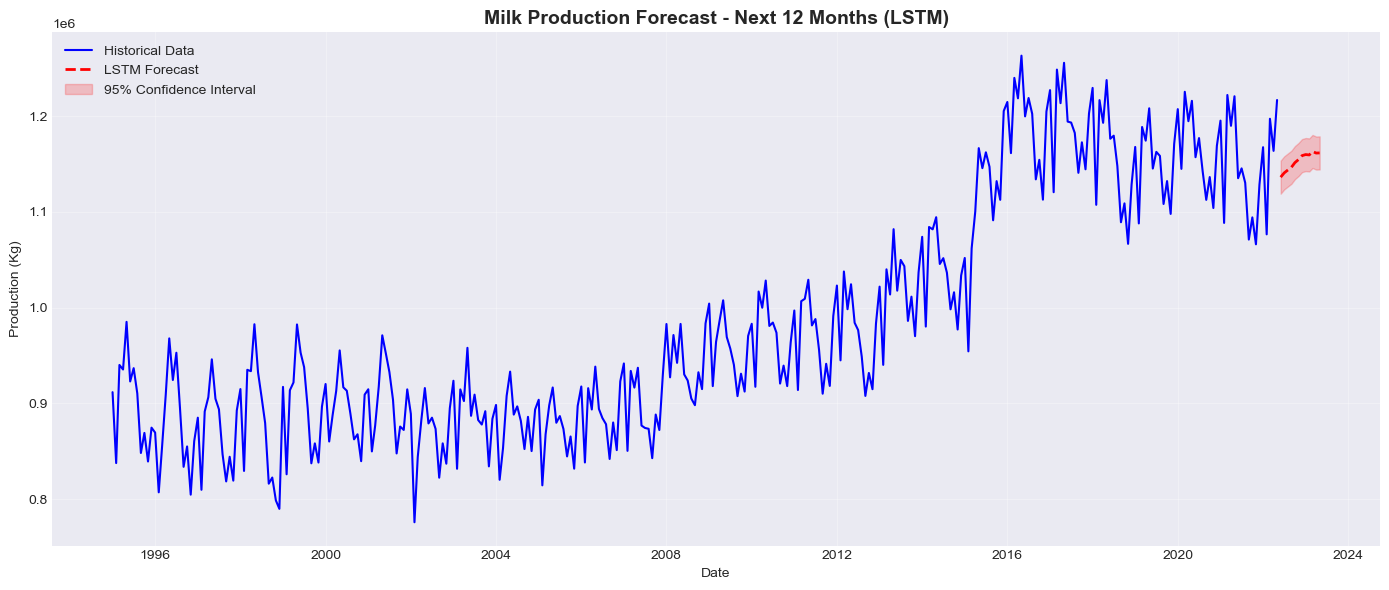

In [99]:
# Cell 5: Visualize Final Forecast
if len(models) > 0 and future_forecast_final is not None:
    plt.figure(figsize=(14, 6))

    # Historical data
    plt.plot(df.index, df['Production'], label='Historical Data', color='blue', linewidth=1.5)

    # Future forecast
    plt.plot(future_dates_final, future_forecast_final, 
             label=f'{best_model_name} Forecast', 
             color='red', linestyle='--', linewidth=2)

    # Confidence interval
    std_dev = np.std(future_forecast_final)
    plt.fill_between(future_dates_final, 
                     future_forecast_final.flatten() - 1.96 * std_dev,
                     future_forecast_final.flatten() + 1.96 * std_dev,
                     alpha=0.2, color='red', label='95% Confidence Interval')

    plt.title(f'Milk Production Forecast - Next 12 Months ({best_model_name})', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Production (Kg)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No forecast available!")

In [101]:
# Cell 6: Project Summary
if len(models) > 0:
    print("PROJECT COMPLETED!")

    print("\n SUMMARY:")
    print(f"Data Period: {df.index[0].strftime('%Y-%m')} to {df.index[-1].strftime('%Y-%m')}")
    print(f"Total Records: {len(df)}")
    print(f"Best Model: {best_model_name}")
    print(f"RMSE: {best_rmse['RMSE']:.2f}")
    print(f"MAPE: {best_rmse['MAPE (%)']:.2f}%")
    
    if future_forecast_final is not None:
        print(f"Forecast Period: {future_dates_final[0].strftime('%Y-%m')} to {future_dates_final[-1].strftime('%Y-%m')}")

    print("\n KEY INSIGHTS:")
    print("✓ Monthly production shows seasonal pattern (12-month cycle)")
    print("✓ Production has increasing trend over time")
    print(f"✓ {best_model_name} provides most accurate predictions")
    
    if future_forecast_final is not None:
        print(f"✓ Expected production range for next 12 months:")
        print(f"  Min: {future_forecast_final.min():,.0f}")
        print(f"  Max: {future_forecast_final.max():,.0f}")
        print(f"  Average: {future_forecast_final.mean():,.0f}")

    print("MILK PRODUCTION FORECASTING PROJECT COMPLETE!")
else:
    print("No models available! Run SARIMA and LSTM cells first.")

PROJECT COMPLETED!

 SUMMARY:
Data Period: 1995-01 to 2022-05
Total Records: 329
Best Model: LSTM
RMSE: 49495.19
MAPE: 3.59%
Forecast Period: 2022-06 to 2023-05

 KEY INSIGHTS:
✓ Monthly production shows seasonal pattern (12-month cycle)
✓ Production has increasing trend over time
✓ LSTM provides most accurate predictions
✓ Expected production range for next 12 months:
  Min: 1,136,235
  Max: 1,163,056
  Average: 1,153,092
MILK PRODUCTION FORECASTING PROJECT COMPLETE!
